# Torch nn.Module and nn.Lineear


In [1]:
import torch
from torch import nn


class LinearRegression(nn.Module):
    def __init__(self):
        super(LinearRegression, self).__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LinearRegression().to(device)

checkpoint = {
    'Model': model.state_dict(),
    'Optim': {"dummy":1}
}
torch.save(checkpoint, 'model.pth')

model.state_dict()

OrderedDict([('linear.weight', tensor([[0.4548]], device='cuda:0')),
             ('linear.bias', tensor([0.2021], device='cuda:0'))])

### Foward Pass

In [2]:
x = torch.Tensor([1]).to(device)
print(f"model({x.item()}) = {model(x).item()}")
print(f"model.forward({x.item()}) = {model.forward(x).item()}")

model(1.0) = 0.6568552255630493
model.forward(1.0) = 0.6568552255630493


In [3]:
ch2 = torch.load('model.pth')

print(ch2)
model.load_state_dict(ch2['Model'])

model.state_dict()

{'Model': OrderedDict([('linear.weight', tensor([[0.4548]], device='cuda:0')), ('linear.bias', tensor([0.2021], device='cuda:0'))]), 'Optim': {'dummy': 1}}


OrderedDict([('linear.weight', tensor([[0.4548]], device='cuda:0')),
             ('linear.bias', tensor([0.2021], device='cuda:0'))])

# Torch Training Loop

### Synthetic Data Generation`

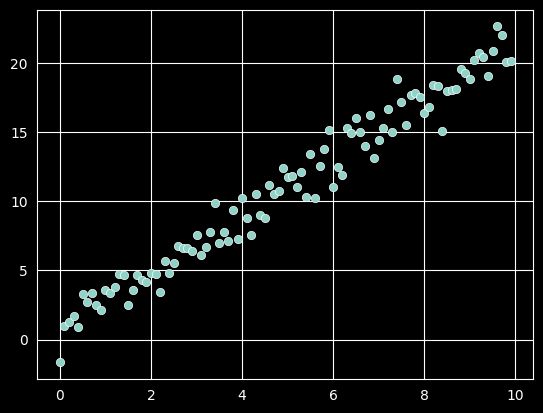

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

x = np.arange(0, 10, 0.1)
noise = np.random.normal(0, 1, len(x))

y = 2*x + 1 + noise

sns.scatterplot(x = x, y = y)
plt.show()

2.04606556892395*x + 0.9162127375602722


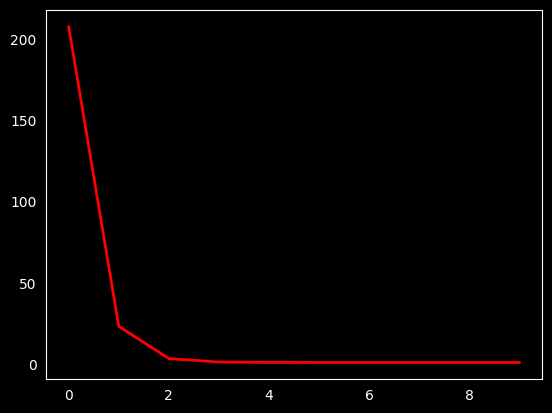

In [25]:
from torch import optim


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tensor_x = torch.tensor(x).float().to(device).view(-1, 1)
tensor_y = torch.tensor(y).float().to(device).view(-1, 1)

model = LinearRegression().to(device)


criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)


losses = []
epochs = 10
for epoch in range(epochs):
    predictions = model(tensor_x).float()

    loss = criterion(predictions, tensor_y)
    losses.append(loss.detach().item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()



w_np = model.linear.weight.detach().item()
b_np = model.linear.bias.detach().item()
print(f'{w_np}*x + {b_np}')

plt.plot(np.arange(0, epochs, 1), losses, color='red', linewidth=2)
plt.grid(False)
plt.show()

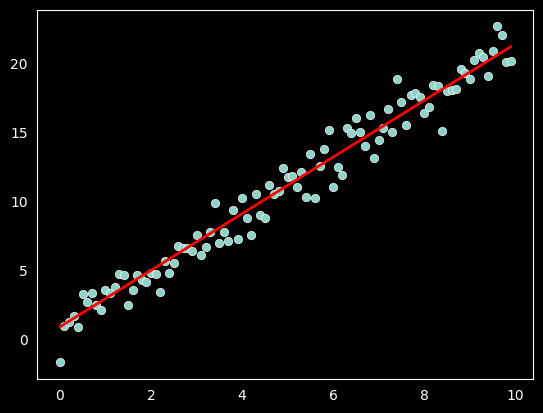

In [26]:
sns.scatterplot(x = x, y = y)

x_s = np.arange(0, 10, 1)
plt.plot(x, w_np*x + b_np, color='red', linewidth=2)
plt.grid(False)
plt.show()